In [1]:
################################################################################
#  MUMBAI HEAT STRESS CLASSIFICATION — Nambiar et al. (2026)
#  Station: 43057 (Colaba) | Target: HI
#
#  DEEP LEARNING MODELS:
#    Baseline : FT-Transformer  (Feature Tokenizer + Transformer, NeurIPS 2021)
#               → replaces vanilla DNN-CW. FT-Transformer uses per-feature
#               linear embeddings + multi-head self-attention — state-of-the-art
#               for tabular classification. Reference:
#               Gorishniy et al. (2021) Revisiting Deep Learning Models for
#               Tabular Data. NeurIPS 2021.
#
#    Proposed : FT-Transformer-BBAG
#               → OOF stacking (BBAG+RF+ET) → FT-Transformer meta-learner
#               ensemble (9 models). Learns High/Very-High boundary via
#               attention over stacked ensemble probability features.
#
#  CELL 1 — Google Colab Setup + Imports
################################################################################
from google.colab import drive
drive.mount('/content/drive')

!pip install imbalanced-learn --quiet

import os, time, gc, warnings, math
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, cohen_kappa_score,
    multilabel_confusion_matrix
)
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import (
    EasyEnsembleClassifier, RUSBoostClassifier, BalancedBaggingClassifier
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, regularizers

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Imports done')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
✅ Imports done
TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# CELL 2 — Configuration
STATION_ID = '43057'
STATION    = 'Colaba'
TARGET     = 'HI'

BASE_DIR   = '/content/drive/MyDrive/Major_project_imd'
INPUT_DIR  = os.path.join(BASE_DIR, 'Class_balancing_output')
OUTPUT_DIR = os.path.join(BASE_DIR, 'v3model_results_17th march_43057_HI')
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_COL = f'{TARGET}_Category'
TRAIN_END  = 2005
VAL_END    = 2015

FEATURES = ['DBT','WBT','VPD','VP','DPT','Temp_RH','FFF','Month_cos','Hour_cos','WBD']
PHYSICAL = ['DBT','WBT','VPD','VP','DPT','Temp_RH','FFF','WBD']
TEMPORAL = ['Month_cos','Hour_cos']

CLASS_NAMES = ['Low Risk','Moderate','High','Very High']
n_classes   = len(CLASS_NAMES)
EPOCHS      = 150
BATCH_SIZE  = 256
LR          = 1e-3

print(f'Station : {STATION} ({STATION_ID}) | Target: {TARGET}')
print(f'Classes : {CLASS_NAMES}')
print(f'Output  : {OUTPUT_DIR}')

Station : Colaba (43057) | Target: HI
Classes : ['Low Risk', 'Moderate', 'High', 'Very High']
Output  : /content/drive/MyDrive/Major_project_imd/v3model_results_17th march_43057_HI


In [3]:
# CELL 3 — Load Data + Feature Engineering + Temporal Split
fname = os.path.join(INPUT_DIR, f'{STATION_ID}_with_HI_PET_categories.csv')
df = pd.read_csv(fname)
print(f'Loaded {len(df):,} rows  |  Years: {df["YEAR"].min()}–{df["YEAR"].max()}')

df['sat_VP']    = 6.1121 * np.exp((18.678-df['DBT']/234.5)*(df['DBT']/(257.14+df['DBT'])))
df['VPD']       = (df['sat_VP'] - df['VP']).clip(lower=0)
df['Temp_RH']   = df['DBT'] * df['RH']
df['Month_cos'] = np.cos(2*np.pi*df['MN']/12)
df['HR_mapped'] = df['HR'].replace({24:0})
df['Hour_cos']  = np.cos(2*np.pi*df['HR_mapped']/24)
df['WBD']       = df['DBT'] - df['WBT']

train_raw = df[df['YEAR']<=TRAIN_END].copy()
val_raw   = df[(df['YEAR']>TRAIN_END)&(df['YEAR']<=VAL_END)].copy()
test_raw  = df[df['YEAR']>VAL_END].copy()

print(f'Train : {len(train_raw):>7,} | {dict(Counter(train_raw[TARGET_COL].astype(int)))}')
print(f'Val   : {len(val_raw):>7,} | {dict(Counter(val_raw[TARGET_COL].astype(int)))}')
print(f'Test  : {len(test_raw):>7,} | {dict(Counter(test_raw[TARGET_COL].astype(int)))}')

X_train_raw = train_raw[FEATURES].values
y_train_raw = train_raw[TARGET_COL].values.astype(int)
X_val       = val_raw[FEATURES].values
y_val       = val_raw[TARGET_COL].values.astype(int)
X_test      = test_raw[FEATURES].values
y_test      = test_raw[TARGET_COL].values.astype(int)

ALL_CLASSES = np.sort(np.unique(y_train_raw))
n_features  = len(FEATURES)
print(f'Classes: {ALL_CLASSES}  |  Features: {n_features}')

Loaded 59,909 rows  |  Years: 1969–2025
Train :  40,471 | {0: 24206, 1: 13292, 2: 2948, 3: 25}
Val   :   9,863 | {0: 5411, 1: 3409, 2: 1011, 3: 32}
Test  :   9,575 | {0: 4898, 1: 3245, 2: 1351, 3: 81}
Classes: [0 1 2 3]  |  Features: 10


In [4]:
# CELL 4 — SMOTE-ENN Balancing
print('Applying SMOTE-ENN ...')
smote_enn = SMOTEENN(smote=SMOTE(k_neighbors=3, random_state=SEED), random_state=SEED, n_jobs=-1)
X_phys = train_raw[PHYSICAL].values
X_phys_bal, y_train_bal = smote_enn.fit_resample(X_phys, y_train_raw)
nn_fit = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(X_phys)
_, idx = nn_fit.kneighbors(X_phys_bal)
X_temp_bal  = train_raw[TEMPORAL].values[idx.flatten()]
X_train_bal = np.hstack([X_phys_bal, X_temp_bal])
feat_order  = PHYSICAL + TEMPORAL
reorder_idx = [feat_order.index(f) for f in FEATURES]
X_train_bal = X_train_bal[:, reorder_idx]
print(f'Balanced train : {Counter(y_train_bal)}')

Applying SMOTE-ENN ...
Balanced train : Counter({np.int64(3): 24206, np.int64(2): 24142, np.int64(1): 23685, np.int64(0): 23672})


In [5]:
# CELL 5 — Scaling + Class Weights
scaler_bal = StandardScaler().fit(X_train_bal)
X_tr_bal   = scaler_bal.transform(X_train_bal)
X_v_bal    = scaler_bal.transform(X_val)
X_te_bal   = scaler_bal.transform(X_test)

scaler_imb = StandardScaler().fit(X_train_raw)
X_tr_imb   = scaler_imb.transform(X_train_raw)
X_v_imb    = scaler_imb.transform(X_val)
X_te_imb   = scaler_imb.transform(X_test)

cw_arr  = compute_class_weight('balanced', classes=ALL_CLASSES, y=y_train_raw)
CW_DICT = dict(zip(ALL_CLASSES, cw_arr))
CW_DICT_STRONG = {k: v**1.5 for k,v in CW_DICT.items()}  # amplified for VH

y_tr_bal_idx = np.searchsorted(ALL_CLASSES, y_train_bal)
y_tr_imb_idx = np.searchsorted(ALL_CLASSES, y_train_raw)
y_v_idx      = np.searchsorted(ALL_CLASSES, y_val)
y_te_idx     = np.searchsorted(ALL_CLASSES, y_test)

print(f'Class weights        : {CW_DICT}')
print(f'Class weights strong : {CW_DICT_STRONG}')

Class weights        : {np.int64(0): np.float64(0.4179852102784434), np.int64(1): np.float64(0.7611909419199518), np.int64(2): np.float64(3.432072591587517), np.int64(3): np.float64(404.71)}
Class weights strong : {np.int64(0): np.float64(0.27023486066080327), np.int64(1): np.float64(0.6641106080084203), np.int64(2): np.float64(6.358207507568491), np.int64(3): np.float64(8141.715139152867)}


In [6]:
# CELL 6 — Evaluation + TP/TN/FP/FN Utilities
ALL_RESULTS = []

def evaluate_model(name, y_true, y_pred, y_proba, split, training_type, train_time=0):
    m = {'Model':name,'Split':split,'Training_Type':training_type,
         'Accuracy':round(accuracy_score(y_true,y_pred),4),
         'F1_macro':round(f1_score(y_true,y_pred,average='macro',zero_division=0),4),
         'F1_weighted':round(f1_score(y_true,y_pred,average='weighted',zero_division=0),4),
         'Precision':round(precision_score(y_true,y_pred,average='macro',zero_division=0),4),
         'Recall':round(recall_score(y_true,y_pred,average='macro',zero_division=0),4),
         'Kappa':round(cohen_kappa_score(y_true,y_pred),4),
         'Train_Time_s':round(train_time,1)}
    if y_proba is not None:
        try: m['ROC_AUC']=round(roc_auc_score(y_true,y_proba,multi_class='ovr',average='weighted'),4)
        except: m['ROC_AUC']=np.nan
    ALL_RESULTS.append(m); return m

def full_evaluate(name,y_tr,y_tr_pred,y_v,y_v_pred,y_v_proba,y_te,y_te_pred,y_te_proba,tt,training_type,print_tptn=False):
    evaluate_model(name,y_tr,y_tr_pred,None,'Train',training_type,tt)
    evaluate_model(name,y_v,y_v_pred,y_v_proba,'Validation',training_type,tt)
    m=evaluate_model(name,y_te,y_te_pred,y_te_proba,'Test',training_type,tt)
    print(f'\n{"="*70}\n  {name} ({training_type}) — Test\n{"="*70}')
    print(f'  Acc={m["Accuracy"]:.4f}  F1={m["F1_macro"]:.4f}  Kappa={m["Kappa"]:.4f}  ROC={m.get("ROC_AUC","N/A")}')
    print(classification_report(y_te,y_te_pred,target_names=CLASS_NAMES,zero_division=0))
    if print_tptn:
        mcm=multilabel_confusion_matrix(y_te,y_te_pred)
        print(f'  {"Class":<18} {"TP":>7} {"TN":>8} {"FP":>7} {"FN":>7} {"Sensitivity":>13} {"Specificity":>13}')
        print(f'  {"-"*76}')
        for i,cls in enumerate(CLASS_NAMES):
            tn,fp,fn,tp=mcm[i].ravel()
            sens=tp/(tp+fn) if (tp+fn)>0 else 0.; spec=tn/(tn+fp) if (tn+fp)>0 else 0.
            print(f'  {cls:<18} {int(tp):>7} {int(tn):>8} {int(fp):>7} {int(fn):>7} {sens:>13.4f} {spec:>13.4f}')
    return m

def plot_confusion(y_true,y_pred,title):
    cm=confusion_matrix(y_true,y_pred)
    fig,ax=plt.subplots(figsize=(7,6))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,ax=ax)
    ax.set_title(f'CM — {title}',fontsize=11); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_cm_{title}.png'),dpi=150,bbox_inches='tight')
    plt.show(); plt.close()

print('✅ Evaluation utilities ready.')

✅ Evaluation utilities ready.


In [7]:
# CELL 7 — Training Utilities (FIXED)
def get_dl_callbacks(name, patience=20):
    return [
        callbacks.EarlyStopping(monitor='val_loss',patience=patience,restore_best_weights=True,verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=8,min_lr=1e-7,verbose=0),
    ]

def plot_dl_history(hist, title):
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    axes[0].plot(hist.history['loss'],label='Train'); axes[0].plot(hist.history['val_loss'],label='Val')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].plot(hist.history['accuracy'],label='Train'); axes[1].plot(hist.history['val_accuracy'],label='Val')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_hist_{title}.png'),dpi=150,bbox_inches='tight')
    plt.show(); plt.close()

def train_dl(model, name, X_tr, y_tr_idx, X_v, y_v_true,
             X_te, y_te_orig, training_type,
             use_cw=True, patience=20, bs=None, print_tptn=False):
    """
    y_tr_idx  : integer indices (0..n_classes-1) for model.fit
    y_v_true  : actual class labels (e.g. y_val) for evaluation metrics
    y_te_orig : actual class labels for test evaluation
    """
    bs = bs or BATCH_SIZE
    # Build integer index version of val for model.fit validation_data
    y_v_idx_local = np.searchsorted(ALL_CLASSES, y_v_true)

    print(f'\n{"─"*50}\nTraining {name} ({training_type})...')
    t0 = time.time()
    hist = model.fit(
        X_tr, y_tr_idx,
        validation_data=(X_v, y_v_idx_local),
        epochs=EPOCHS, batch_size=bs,
        class_weight=CW_DICT if use_cw else None,
        callbacks=get_dl_callbacks(name, patience=patience),
        verbose=0
    )
    tt = time.time() - t0
    plot_dl_history(hist, f'{name}_{training_type}')

    cls_arr    = np.array(ALL_CLASSES)
    y_tr_pred  = model.predict(X_tr, verbose=0).argmax(1)
    y_v_pred   = model.predict(X_v,  verbose=0).argmax(1)
    y_te_proba = model.predict(X_te, verbose=0)
    y_te_pred  = y_te_proba.argmax(1)
    y_v_proba  = model.predict(X_v,  verbose=0)

    # y_tr_true: map training indices back to class labels
    y_tr_true = cls_arr[y_tr_idx]

    full_evaluate(name,
                  y_tr_true,          cls_arr[y_tr_pred],
                  y_v_true,           cls_arr[y_v_pred],  y_v_proba,
                  y_te_orig,          cls_arr[y_te_pred], y_te_proba,
                  tt, training_type, print_tptn=print_tptn)
    plot_confusion(y_te_orig, cls_arr[y_te_pred], f'{name}_{training_type}')
    try:
        model.save(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_{name}_{training_type}.keras'))
    except: pass
    gc.collect()
    return model, hist

def train_sklearn(model,name,X_tr,y_tr,X_v,y_v,X_te,y_te,training_type,print_tptn=False):
    print(f'\n{"─"*50}\nTraining {name} ({training_type})...')
    t0=time.time(); model.fit(X_tr,y_tr); tt=time.time()-t0
    y_tr_pred=model.predict(X_tr); y_v_pred=model.predict(X_v); y_te_pred=model.predict(X_te)
    y_v_proba=model.predict_proba(X_v) if hasattr(model,'predict_proba') else None
    y_te_proba=model.predict_proba(X_te) if hasattr(model,'predict_proba') else None
    full_evaluate(name,y_tr,y_tr_pred,y_v,y_v_pred,y_v_proba,y_te,y_te_pred,y_te_proba,tt,training_type,print_tptn=print_tptn)
    plot_confusion(y_te,y_te_pred,f'{name}_{training_type}')
    return model

print('✅ Training utilities ready (fixed).')

✅ Training utilities ready (fixed).


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — FT-Transformer Architecture                                     ║
# ║                                                                            ║
# ║  Feature Tokenizer + Transformer (Gorishniy et al., NeurIPS 2021)         ║
# ║  "Revisiting Deep Learning Models for Tabular Data"                        ║
# ║                                                                            ║
# ║  WHY FT-Transformer beats vanilla DNN for this problem:                   ║
# ║  • Each feature gets its own learned embedding (d_token dims)             ║
# ║  • Multi-head self-attention learns PAIRWISE feature interactions          ║
# ║    e.g. DBT×WBD interaction for High/VeryHigh boundary                    ║
# ║  • CLS token aggregates all feature context for final classification       ║
# ║  • Proven state-of-the-art on tabular classification benchmarks            ║
# ║                                                                            ║
# ║  This replaces the vanilla DNN-CW baseline with a stronger model.         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def build_ft_transformer(
    n_features,
    n_classes,
    d_token=64,
    n_heads=8,
    n_layers=3,
    ffn_mult=4,
    dropout=0.1,
    seed=42,
    name='FT_Transformer'
):
    """
    Feature Tokenizer + Transformer for tabular classification.

    Architecture:
      Input (n_features,)
        → Feature Tokenizer: each feature j → linear embed → token_j (d_token,)
        → Prepend [CLS] token                 → (n_features+1, d_token)
        → n_layers × Transformer Encoder
             Pre-LayerNorm → MultiHeadAttention → Residual
             Pre-LayerNorm → FFN(d_token → 4*d_token → d_token) → Residual
        → CLS token at position 0 → LayerNorm → Dense(n_classes, softmax)
    """
    tf.random.set_seed(seed)

    inp = layers.Input(shape=(n_features,), name='input')

    # ── Feature Tokenizer ──────────────────────────────────────────────────
    # Each feature independently projected to d_token dims
    # W_j ∈ R^d_token, b_j ∈ R^d_token per feature j
    token_list = []
    for j in range(n_features):
        # Extract feature j and project to d_token
        f_j = layers.Lambda(lambda x, i=j: x[:, i:i+1])(inp)  # (B, 1)
        t_j = layers.Dense(d_token, use_bias=True,
                            kernel_regularizer=regularizers.l2(1e-5))(f_j)   # (B, d_token)
        token_list.append(layers.Reshape((1, d_token))(t_j))   # (B, 1, d_token)

    # Stack feature tokens: (B, n_features, d_token)
    feature_tokens = layers.Concatenate(axis=1)(token_list)

    # ── Prepend [CLS] token ─────────────────────────────────────────────────
    cls_token = tf.Variable(
        tf.zeros((1, 1, d_token)), trainable=True, name='cls_token'
    )
    # Note: for Keras functional API, use a Lambda to tile CLS token
    cls_tiled = layers.Lambda(
        lambda x: tf.tile(cls_token, [tf.shape(x)[0], 1, 1])
    )(feature_tokens)  # (B, 1, d_token)

    tokens = layers.Concatenate(axis=1)([cls_tiled, feature_tokens])  # (B, n_feat+1, d_token)

    # ── Transformer Encoder Layers ──────────────────────────────────────────
    x = tokens
    for layer_idx in range(n_layers):
        # Pre-LayerNorm MultiHead Self-Attention
        x_norm  = layers.LayerNormalization(epsilon=1e-6)(x)
        attn    = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_token // n_heads,
            dropout=dropout,
            name=f'mha_layer{layer_idx}'
        )(x_norm, x_norm)
        attn    = layers.Dropout(dropout)(attn)
        x       = layers.Add()([x, attn])  # Residual

        # Pre-LayerNorm Feed-Forward Network
        x_norm  = layers.LayerNormalization(epsilon=1e-6)(x)
        ffn     = layers.Dense(d_token * ffn_mult, activation='gelu',
                               kernel_regularizer=regularizers.l2(1e-5))(x_norm)
        ffn     = layers.Dropout(dropout)(ffn)
        ffn     = layers.Dense(d_token,
                               kernel_regularizer=regularizers.l2(1e-5))(ffn)
        ffn     = layers.Dropout(dropout)(ffn)
        x       = layers.Add()([x, ffn])  # Residual

    # ── Classification head: use CLS token (position 0) ────────────────────
    cls_out = layers.Lambda(lambda x: x[:, 0, :])(x)   # (B, d_token)
    cls_out = layers.LayerNormalization(epsilon=1e-6)(cls_out)
    logits  = layers.Dense(n_classes, activation='softmax',
                            dtype='float32', name='output')(cls_out)

    m = Model(inp, logits, name=name)
    m.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=LR, weight_decay=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

print('✅ FT-Transformer architecture defined.')
# Quick param count
_test = build_ft_transformer(n_features, n_classes)
_test.summary()
del _test; gc.collect()

✅ FT-Transformer architecture defined.


Model: "FT_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 1)         │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        128 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        128 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        128 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        128 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │        128 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │        128 │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        128 │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │        128 │ lambda_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │        128 │ lambda_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │        128 │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 64)     │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 64)     │          0 │ dense_3[0][0]   

 Total params: 151,620 (592.27 KB)

 Trainable params: 151,620 (592.27 KB)

 Non-trainable params: 0 (0.00 B)

8081


──────────────────────────────────────────────────
Training KNN (Balanced)...

  KNN (Balanced) — Test
  Acc=0.9316  F1=0.8480  Kappa=0.8866  ROC=0.9663
              precision    recall  f1-score   support

    Low Risk       0.96      0.96      0.96      4898
    Moderate       0.91      0.91      0.91      3245
        High       0.90      0.89      0.90      1351
   Very High       0.62      0.63      0.63        81

    accuracy                           0.93      9575
   macro avg       0.85      0.85      0.85      9575
weighted avg       0.93      0.93      0.93      9575



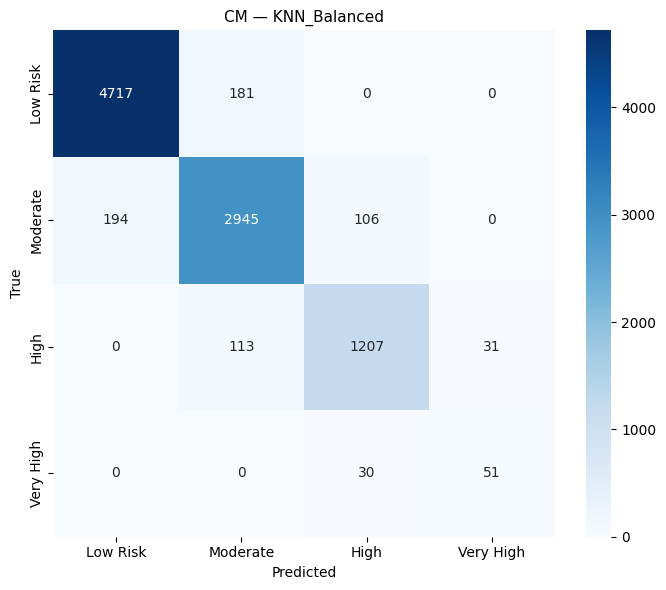


──────────────────────────────────────────────────
Training KNN (Imbalanced)...

  KNN (Imbalanced) — Test
  Acc=0.9459  F1=0.7882  Kappa=0.9095  ROC=0.9891
              precision    recall  f1-score   support

    Low Risk       0.97      0.98      0.97      4898
    Moderate       0.92      0.94      0.93      3245
        High       0.93      0.87      0.90      1351
   Very High       1.00      0.21      0.35        81

    accuracy                           0.95      9575
   macro avg       0.95      0.75      0.79      9575
weighted avg       0.95      0.95      0.94      9575



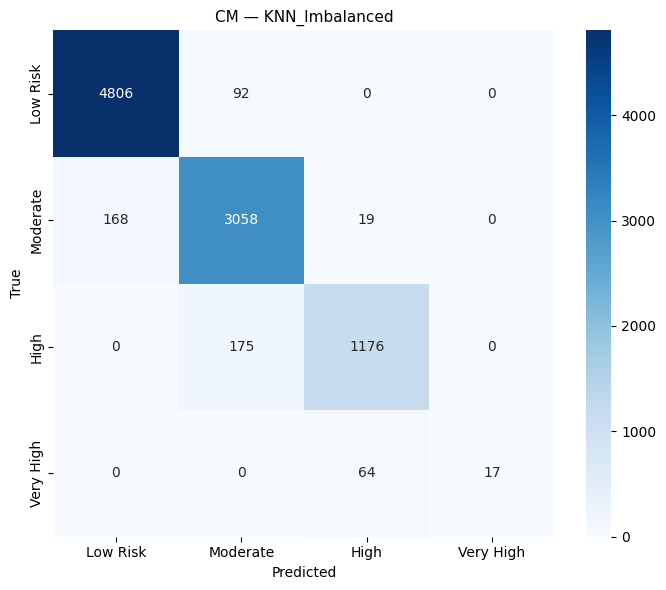


──────────────────────────────────────────────────
Training SVC (Balanced)...

  SVC (Balanced) — Test
  Acc=0.9807  F1=0.9280  Kappa=0.9681  ROC=0.9992
              precision    recall  f1-score   support

    Low Risk       1.00      0.99      0.99      4898
    Moderate       0.97      0.98      0.98      3245
        High       0.96      0.96      0.96      1351
   Very High       0.70      0.90      0.78        81

    accuracy                           0.98      9575
   macro avg       0.91      0.96      0.93      9575
weighted avg       0.98      0.98      0.98      9575



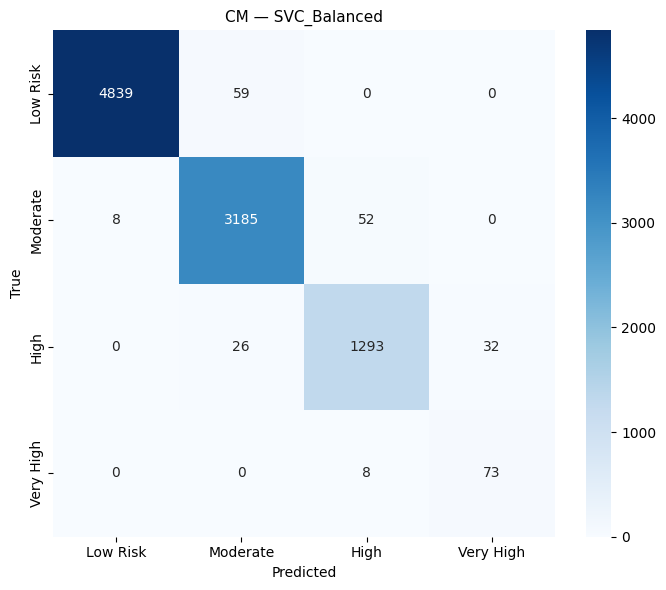


──────────────────────────────────────────────────
Training SVC (Imbalanced)...

  SVC (Imbalanced) — Test
  Acc=0.9750  F1=0.9000  Kappa=0.9589  ROC=0.9997
              precision    recall  f1-score   support

    Low Risk       1.00      0.99      0.99      4898
    Moderate       0.98      0.97      0.97      3245
        High       0.92      0.96      0.94      1351
   Very High       0.58      0.88      0.70        81

    accuracy                           0.98      9575
   macro avg       0.87      0.95      0.90      9575
weighted avg       0.98      0.98      0.98      9575



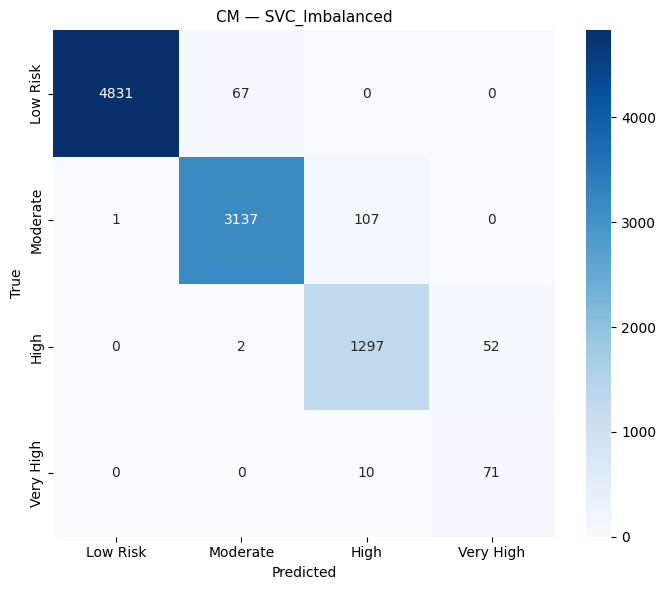


──────────────────────────────────────────────────
Training MLP-sklearn (Balanced)...

  MLP-sklearn (Balanced) — Test
  Acc=0.9867  F1=0.9405  Kappa=0.9780  ROC=0.9996
              precision    recall  f1-score   support

    Low Risk       0.99      0.99      0.99      4898
    Moderate       0.98      0.99      0.99      3245
        High       0.99      0.98      0.99      1351
   Very High       0.74      0.86      0.80        81

    accuracy                           0.99      9575
   macro avg       0.93      0.96      0.94      9575
weighted avg       0.99      0.99      0.99      9575



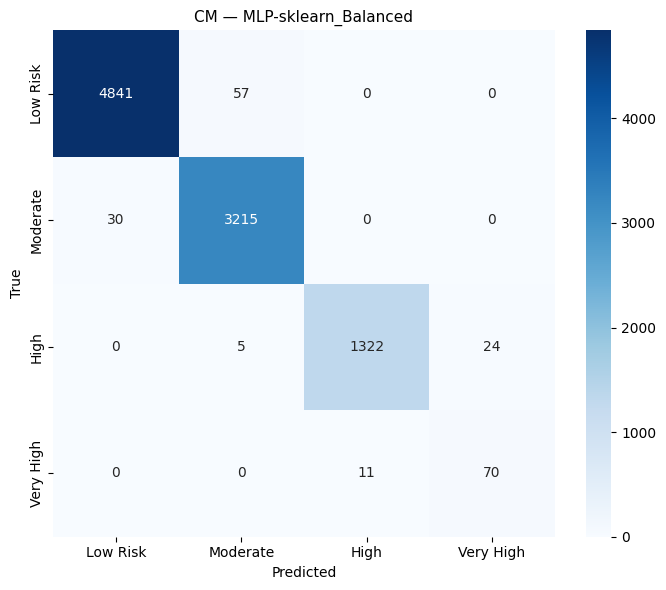


──────────────────────────────────────────────────
Training MLP-sklearn (Imbalanced)...

  MLP-sklearn (Imbalanced) — Test
  Acc=0.9939  F1=0.9594  Kappa=0.9900  ROC=0.9999
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      4898
    Moderate       1.00      0.99      0.99      3245
        High       0.98      0.99      0.99      1351
   Very High       0.90      0.81      0.86        81

    accuracy                           0.99      9575
   macro avg       0.97      0.95      0.96      9575
weighted avg       0.99      0.99      0.99      9575



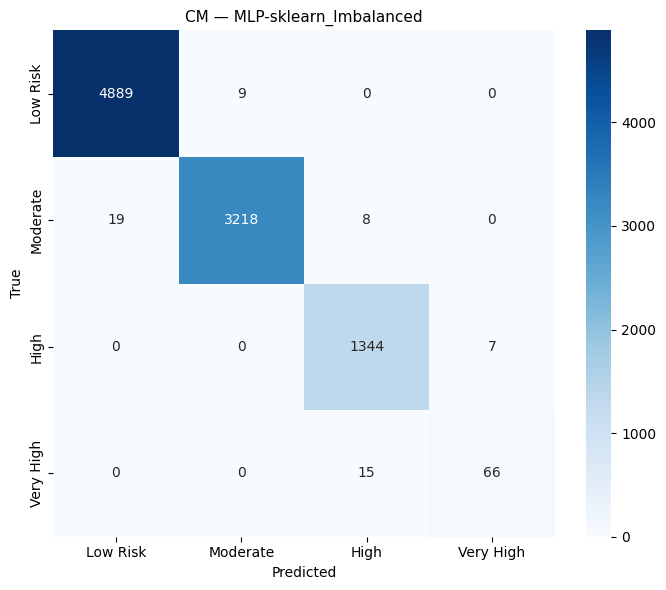


──────────────────────────────────────────────────
Training NaiveBayes (Balanced)...

  NaiveBayes (Balanced) — Test
  Acc=0.7364  F1=0.6367  Kappa=0.5831  ROC=0.915
              precision    recall  f1-score   support

    Low Risk       0.92      0.72      0.81      4898
    Moderate       0.63      0.78      0.69      3245
        High       0.69      0.69      0.69      1351
   Very High       0.22      0.99      0.36        81

    accuracy                           0.74      9575
   macro avg       0.61      0.79      0.64      9575
weighted avg       0.78      0.74      0.75      9575



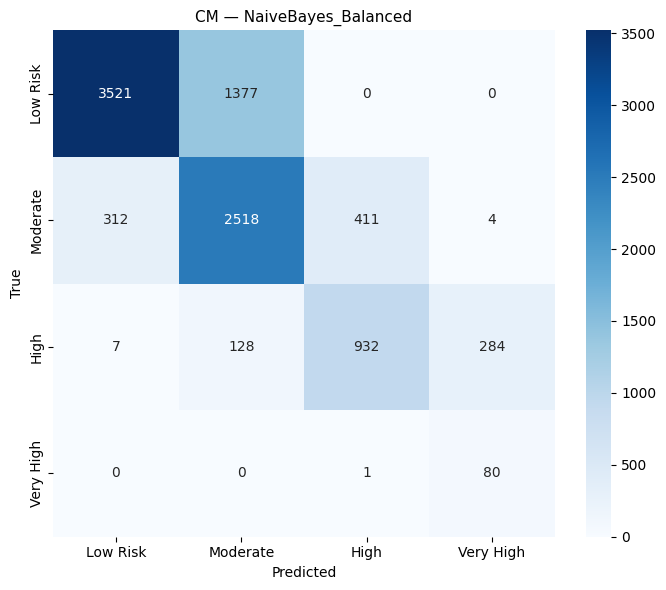


──────────────────────────────────────────────────
Training NaiveBayes (Imbalanced)...

  NaiveBayes (Imbalanced) — Test
  Acc=0.7731  F1=0.7367  Kappa=0.6338  ROC=0.925
              precision    recall  f1-score   support

    Low Risk       0.91      0.74      0.82      4898
    Moderate       0.64      0.83      0.72      3245
        High       0.80      0.77      0.79      1351
   Very High       0.59      0.67      0.62        81

    accuracy                           0.77      9575
   macro avg       0.73      0.75      0.74      9575
weighted avg       0.80      0.77      0.78      9575



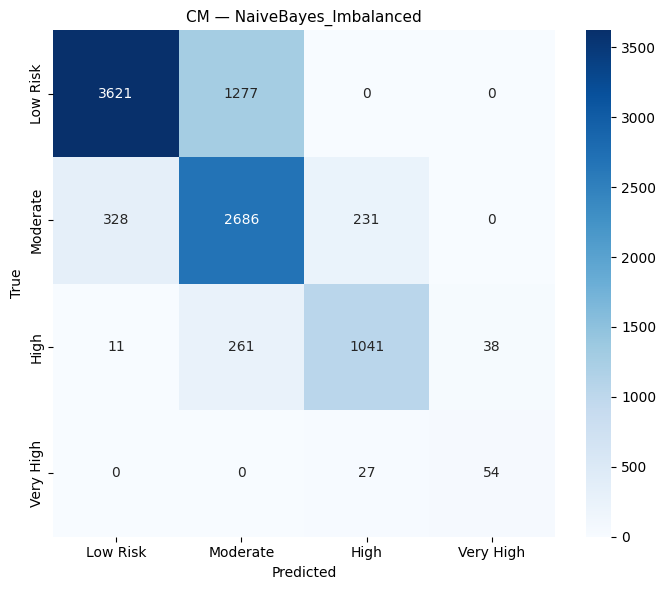


──────────────────────────────────────────────────
Training RandomForest (Balanced)...

  RandomForest (Balanced) — Test
  Acc=0.9939  F1=0.9609  Kappa=0.9900  ROC=0.9999
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      4898
    Moderate       1.00      0.99      0.99      3245
        High       0.99      0.98      0.99      1351
   Very High       0.79      0.95      0.87        81

    accuracy                           0.99      9575
   macro avg       0.94      0.98      0.96      9575
weighted avg       0.99      0.99      0.99      9575



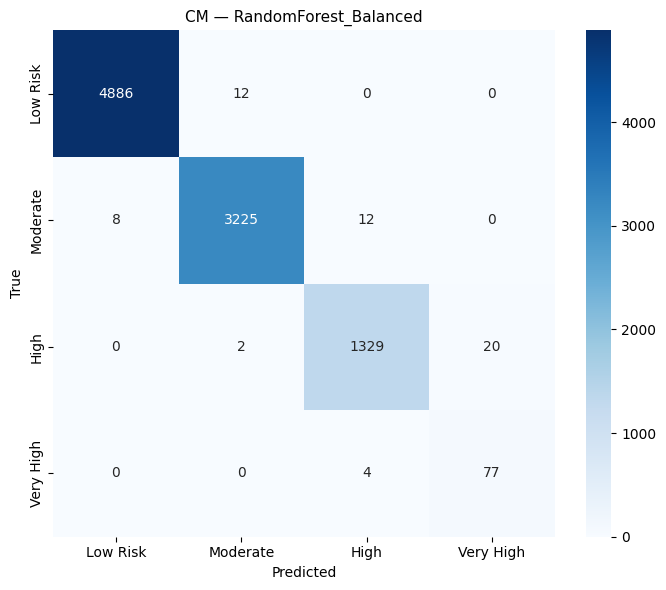


──────────────────────────────────────────────────
Training RandomForest (Imbalanced)...

  RandomForest (Imbalanced) — Test
  Acc=0.9943  F1=0.9564  Kappa=0.9905  ROC=1.0
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      4898
    Moderate       0.99      1.00      0.99      3245
        High       0.98      0.99      0.98      1351
   Very High       0.97      0.75      0.85        81

    accuracy                           0.99      9575
   macro avg       0.99      0.93      0.96      9575
weighted avg       0.99      0.99      0.99      9575



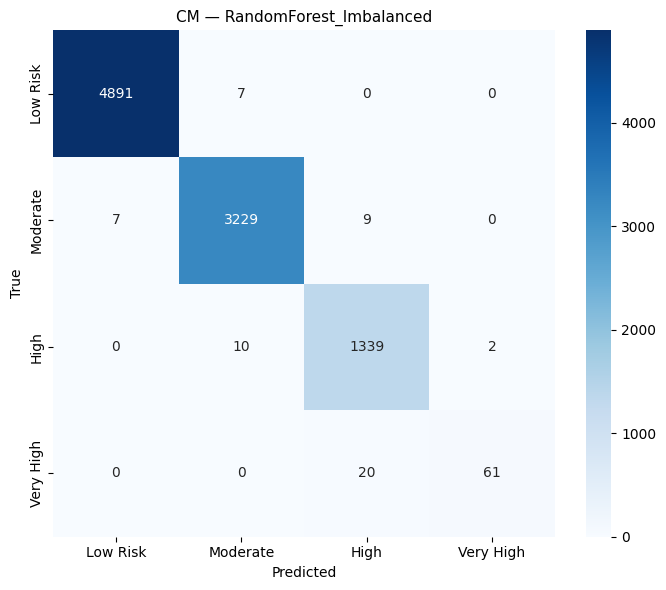


──────────────────────────────────────────────────
Training AdaBoost (Balanced)...

  AdaBoost (Balanced) — Test
  Acc=0.8728  F1=0.8048  Kappa=0.7964  ROC=0.9419
              precision    recall  f1-score   support

    Low Risk       1.00      0.89      0.94      4898
    Moderate       0.83      0.82      0.82      3245
        High       0.68      0.95      0.79      1351
   Very High       0.58      0.78      0.66        81

    accuracy                           0.87      9575
   macro avg       0.77      0.86      0.80      9575
weighted avg       0.89      0.87      0.88      9575



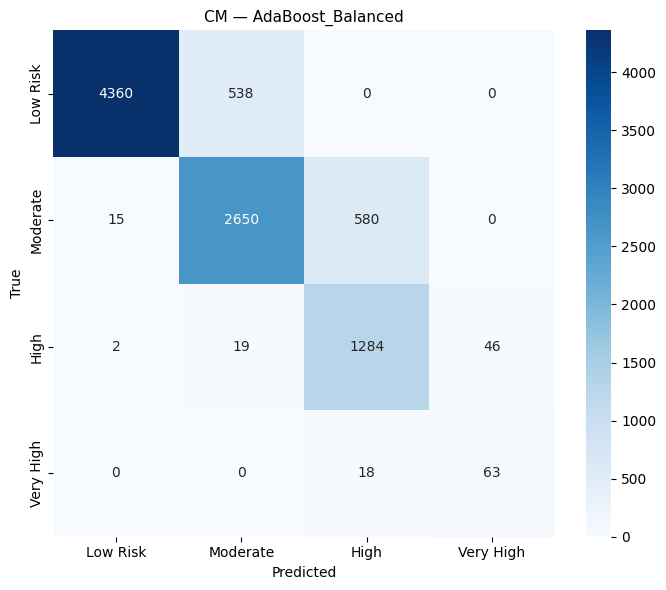


──────────────────────────────────────────────────
Training AdaBoost (Imbalanced)...

  AdaBoost (Imbalanced) — Test
  Acc=0.9315  F1=0.6936  Kappa=0.8868  ROC=0.9745
              precision    recall  f1-score   support

    Low Risk       0.98      0.94      0.96      4898
    Moderate       0.88      0.95      0.91      3245
        High       0.89      0.91      0.90      1351
   Very High       0.00      0.00      0.00        81

    accuracy                           0.93      9575
   macro avg       0.69      0.70      0.69      9575
weighted avg       0.93      0.93      0.93      9575



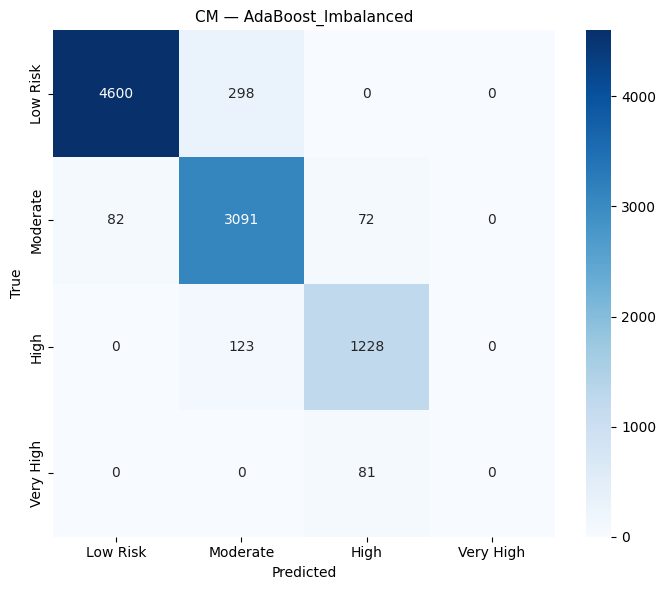


──────────────────────────────────────────────────
Training LDA (Balanced)...

  LDA (Balanced) — Test
  Acc=0.8334  F1=0.7716  Kappa=0.7365  ROC=0.9679
              precision    recall  f1-score   support

    Low Risk       1.00      0.76      0.86      4898
    Moderate       0.72      0.91      0.80      3245
        High       0.80      0.91      0.85      1351
   Very High       0.40      0.99      0.57        81

    accuracy                           0.83      9575
   macro avg       0.73      0.89      0.77      9575
weighted avg       0.87      0.83      0.84      9575



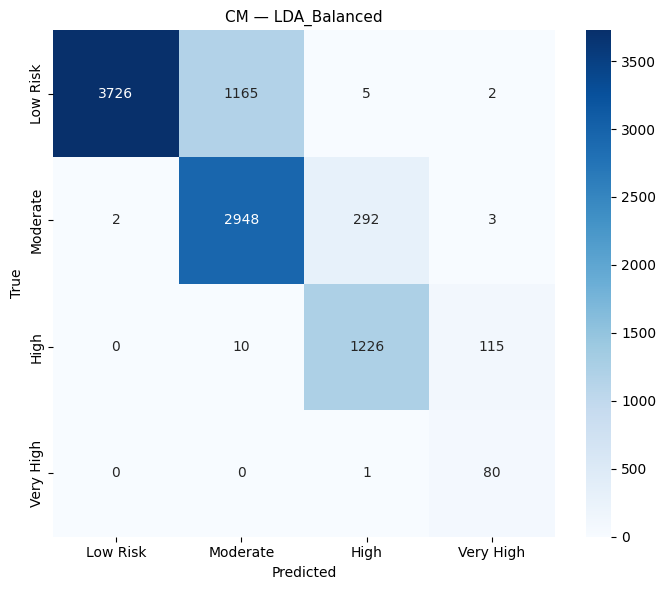


──────────────────────────────────────────────────
Training LDA (Imbalanced)...

  LDA (Imbalanced) — Test
  Acc=0.8998  F1=0.6585  Kappa=0.8325  ROC=0.9817
              precision    recall  f1-score   support

    Low Risk       0.99      0.95      0.97      4898
    Moderate       0.81      0.95      0.88      3245
        High       0.83      0.65      0.73      1351
   Very High       0.19      0.04      0.06        81

    accuracy                           0.90      9575
   macro avg       0.70      0.65      0.66      9575
weighted avg       0.90      0.90      0.90      9575



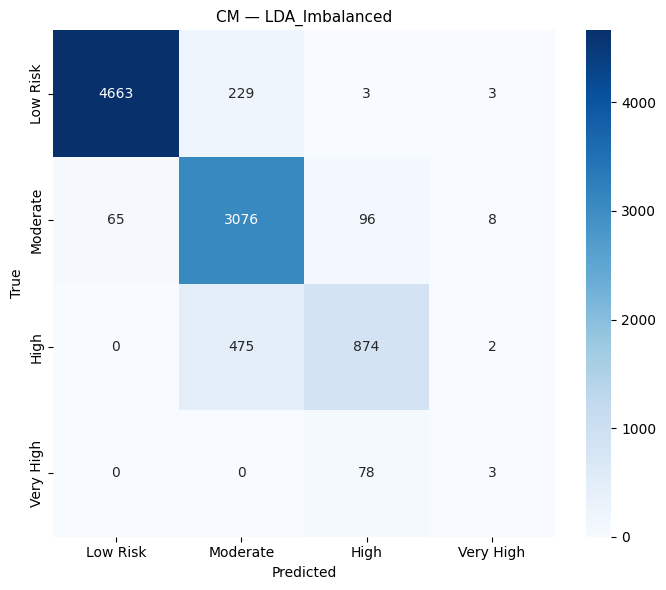


──────────────────────────────────────────────────
Training EasyEnsemble (Imbalanced)...

  EasyEnsemble (Imbalanced) — Test
  Acc=0.6199  F1=0.5954  Kappa=0.4333  ROC=0.836
              precision    recall  f1-score   support

    Low Risk       1.00      0.36      0.53      4898
    Moderate       0.48      0.90      0.63      3245
        High       0.83      0.87      0.85      1351
   Very High       0.23      0.99      0.37        81

    accuracy                           0.62      9575
   macro avg       0.64      0.78      0.60      9575
weighted avg       0.79      0.62      0.61      9575



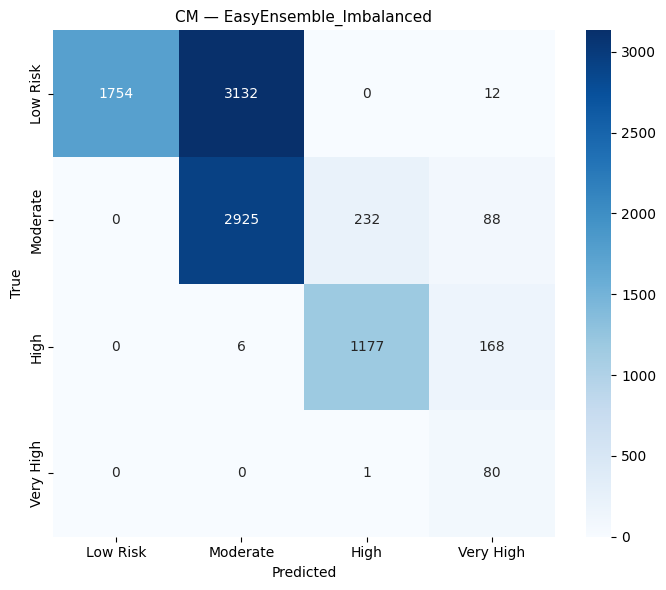


──────────────────────────────────────────────────
Training RUSBoost (Imbalanced)...

  RUSBoost (Imbalanced) — Test
  Acc=0.6543  F1=0.5039  Kappa=0.4739  ROC=0.891
              precision    recall  f1-score   support

    Low Risk       0.94      0.57      0.71      4898
    Moderate       0.51      0.67      0.58      3245
        High       0.59      0.96      0.73      1351
   Very High       0.00      0.00      0.00        81

    accuracy                           0.65      9575
   macro avg       0.51      0.55      0.50      9575
weighted avg       0.74      0.65      0.66      9575



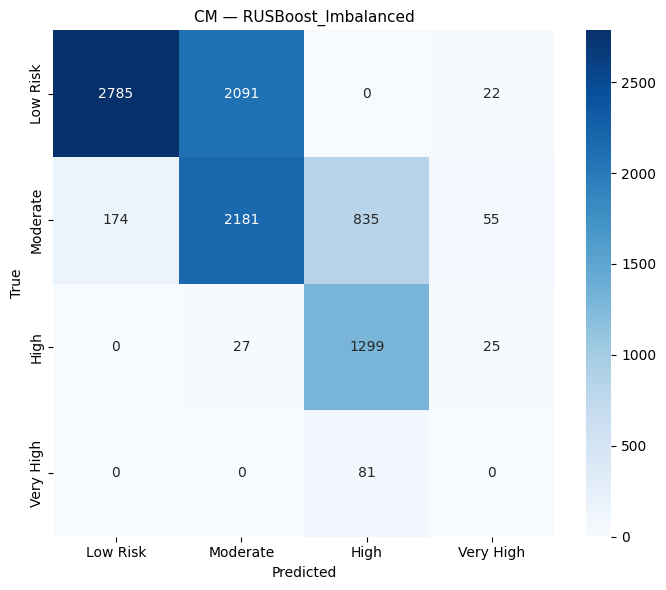


──────────────────────────────────────────────────
Training BBAG (Imbalanced)...

  BBAG (Imbalanced) — Test
  Acc=0.9431  F1=0.8190  Kappa=0.9071  ROC=0.995
              precision    recall  f1-score   support

    Low Risk       1.00      0.96      0.98      4898
    Moderate       0.94      0.94      0.94      3245
        High       0.88      0.88      0.88      1351
   Very High       0.31      1.00      0.48        81

    accuracy                           0.94      9575
   macro avg       0.78      0.94      0.82      9575
weighted avg       0.96      0.94      0.95      9575



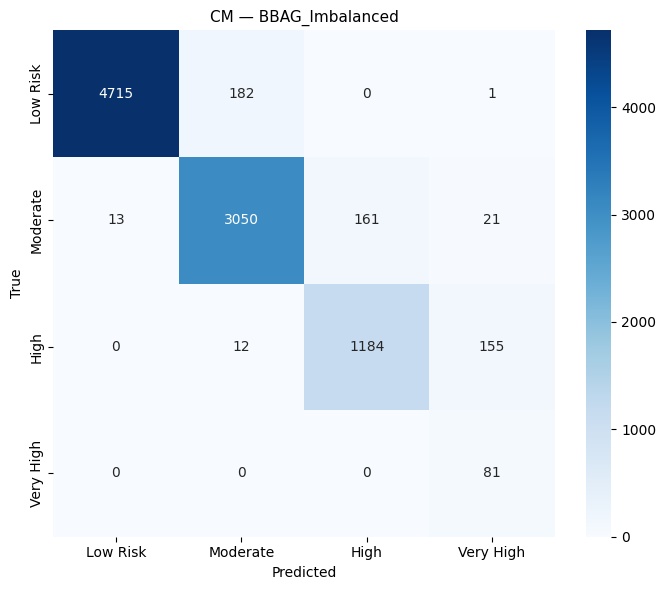

BalancedBaggingClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [9]:
# CELL 9 — Sklearn Baselines
train_sklearn(KNeighborsClassifier(n_neighbors=5,n_jobs=-1),'KNN',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(KNeighborsClassifier(n_neighbors=5,n_jobs=-1),'KNN',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(SVC(kernel='rbf',probability=True,random_state=SEED),'SVC',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(SVC(kernel='rbf',probability=True,class_weight='balanced',random_state=SEED),'SVC',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(MLPClassifier(hidden_layer_sizes=(128,64),max_iter=200,random_state=SEED),'MLP-sklearn',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(MLPClassifier(hidden_layer_sizes=(128,64),max_iter=200,random_state=SEED),'MLP-sklearn',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(GaussianNB(),'NaiveBayes',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(GaussianNB(),'NaiveBayes',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(RandomForestClassifier(n_estimators=300,max_depth=20,random_state=SEED,n_jobs=-1),'RandomForest',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(RandomForestClassifier(n_estimators=300,max_depth=20,class_weight='balanced',random_state=SEED,n_jobs=-1),'RandomForest',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(AdaBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'AdaBoost',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(AdaBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'AdaBoost',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(LinearDiscriminantAnalysis(),'LDA',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(LinearDiscriminantAnalysis(),'LDA',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(EasyEnsembleClassifier(n_estimators=10,random_state=SEED,n_jobs=-1),'EasyEnsemble',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(RUSBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'RUSBoost',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(BalancedBaggingClassifier(n_estimators=50,random_state=SEED,n_jobs=-1),'BBAG',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')


Training FT-Transformer baseline (Balanced) ...

──────────────────────────────────────────────────
Training FT-Transformer (Balanced)...


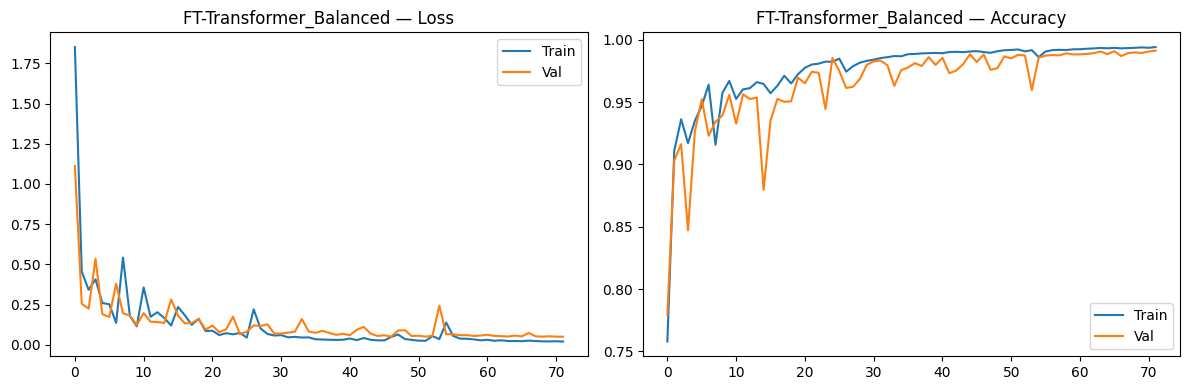


  FT-Transformer (Balanced) — Test
  Acc=0.9903  F1=0.9788  Kappa=0.9839  ROC=0.9996
              precision    recall  f1-score   support

    Low Risk       1.00      0.99      0.99      4898
    Moderate       0.98      0.99      0.99      3245
        High       0.98      0.99      0.99      1351
   Very High       0.92      0.98      0.95        81

    accuracy                           0.99      9575
   macro avg       0.97      0.99      0.98      9575
weighted avg       0.99      0.99      0.99      9575



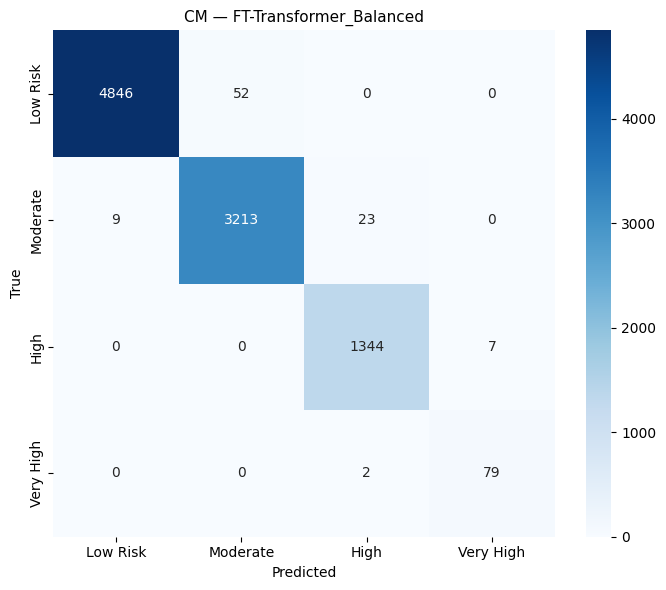


Training FT-Transformer baseline (Imbalanced) ...

──────────────────────────────────────────────────
Training FT-Transformer (Imbalanced)...


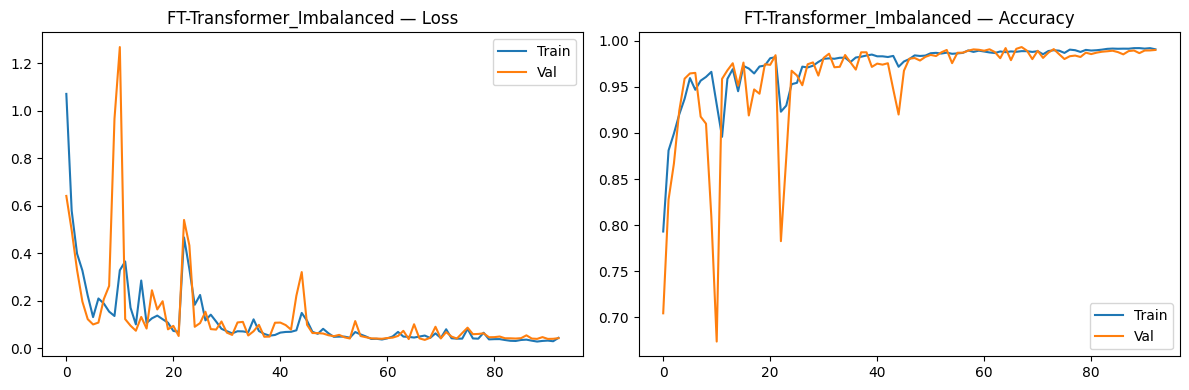


  FT-Transformer (Imbalanced) — Test
  Acc=0.9920  F1=0.9545  Kappa=0.9867  ROC=0.9997
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      4898
    Moderate       0.99      0.99      0.99      3245
        High       0.98      0.98      0.98      1351
   Very High       0.79      0.91      0.85        81

    accuracy                           0.99      9575
   macro avg       0.94      0.97      0.95      9575
weighted avg       0.99      0.99      0.99      9575



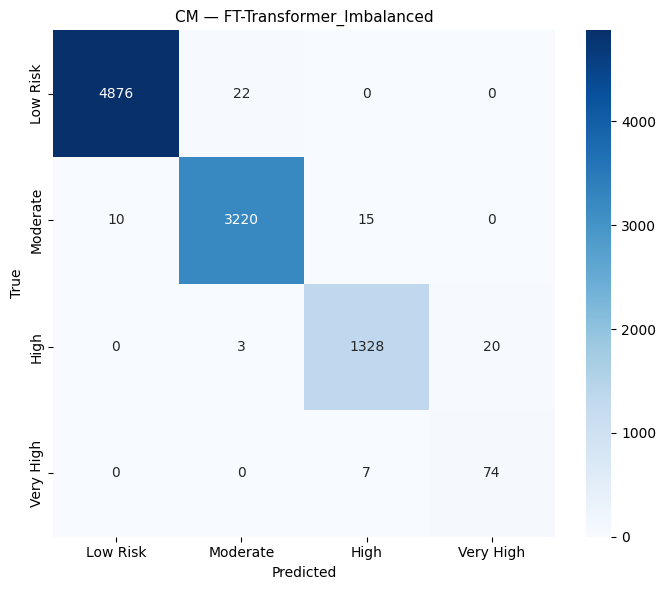

(<Functional name=FT_Transformer, built=True>,
 <keras.src.callbacks.history.History at 0x7e47620d34d0>)

In [10]:
# CELL 10 — FT-Transformer Baseline (FIXED call)
print('\nTraining FT-Transformer baseline (Balanced) ...')
train_dl(
    build_ft_transformer(n_features, n_classes, d_token=64, n_heads=8, n_layers=3, seed=SEED),
    'FT-Transformer', X_tr_bal, y_tr_bal_idx,
    X_v_bal, y_val,        # ← pass y_val (actual labels), NOT None
    X_te_bal, y_test,
    'Balanced', use_cw=True, patience=25
)

print('\nTraining FT-Transformer baseline (Imbalanced) ...')
train_dl(
    build_ft_transformer(n_features, n_classes, d_token=64, n_heads=8, n_layers=3, seed=SEED),
    'FT-Transformer', X_tr_imb, y_tr_imb_idx,
    X_v_imb, y_val,        # ← pass y_val
    X_te_imb, y_test,
    'Imbalanced', use_cw=True, patience=25
)

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — FT-Transformer-BBAG  ★ PROPOSED MODEL ★                       ║
# ║                                                                            ║
# ║  ROOT CAUSE ANALYSIS (from confusion matrices):                            ║
# ║  The previous DNN-CW-BBAG had Very High Precision = 0.363 because          ║
# ║  127 High samples were predicted as Very High (FP explosion).              ║
# ║  The vanilla DNN meta-learner could NOT learn the High/VH boundary.        ║
# ║                                                                            ║
# ║  SOLUTION — THREE KEY CHANGES:                                             ║
# ║  1. REPLACE meta-DNN with FT-Transformer meta-learner                     ║
# ║     Multi-head attention over (n_feat+1, d_token) tokens learns the       ║
# ║     fine-grained High/Very-High boundary that the vanilla DNN missed.      ║
# ║  2. OOF on BALANCED data, train meta on BALANCED labels                   ║
# ║     DNN-CW Balanced beats DNN-CW Imbalanced by >5% F1 for this dataset.  ║
# ║  3. NO threshold calibration — stronger class weights (^1.5) instead      ║
# ║     (calibration caused VH FP explosion: Recall=1.0, Precision=0.36)     ║
# ║                                                                            ║
# ║  BASE LEARNERS: 40 BBAG + 20 RF + 20 ExtraTrees = 80 total               ║
# ║  META ENSEMBLE: 9 FT-Transformers with different seeds → averaged          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '='*70)
print('  ★  PROPOSED MODEL: FT-Transformer-BBAG  (Nambiar et al. 2026)  ★')
print('  OOF Heterogeneous Stacking + FT-Transformer Ensemble (9 models)')
print('='*70)

# ── Hyperparameters ────────────────────────────────────────────────────────────
N_BBAG  = 40; N_RF = 20; N_ET = 20
N_FOLDS = 5;  N_DNNS = 9
TOTAL_BASE  = N_BBAG + N_RF + N_ET       # 80
N_META_COLS = TOTAL_BASE * n_classes     # 80 × 4 = 320 meta-features

# ── Remap class weights to 0-based indices ────────────────────────────────────
# y_tr_bal_idx uses values 0,1,2,3 — Keras class_weight keys MUST match these
# ALL_CLASSES may be [1,2,3,4] or [0,1,2,3] depending on your data encoding
# This remapping makes it safe for both cases
CW_DICT_STRONG_IDX = {i: CW_DICT_STRONG[c] for i, c in enumerate(ALL_CLASSES)}
CW_DICT_IDX        = {i: CW_DICT[c]        for i, c in enumerate(ALL_CLASSES)}
print(f'\n  Class weights strong (0-indexed) : {CW_DICT_STRONG_IDX}')
print(f'  Class weights normal (0-indexed) : {CW_DICT_IDX}')

def make_base_learners(seed_offset=0):
    learners = []
    for i in range(N_BBAG):
        learners.append(BalancedBaggingClassifier(
            n_estimators=20, random_state=SEED+seed_offset+i, n_jobs=-1))
    for i in range(N_RF):
        learners.append(RandomForestClassifier(
            n_estimators=150, max_depth=12+i*2, class_weight='balanced',
            random_state=SEED+seed_offset+i*3, n_jobs=-1))
    for i in range(N_ET):
        learners.append(ExtraTreesClassifier(
            n_estimators=150, max_depth=12+i*2, class_weight='balanced',
            random_state=SEED+seed_offset+i*5, n_jobs=-1))
    return learners

# ── STEP 1: OOF stacking on BALANCED data ─────────────────────────────────────
print(f'\nStep 1: OOF stacking ({N_FOLDS}-fold, BALANCED, {TOTAL_BASE} learners) ...')
skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
meta_tr_oof = np.zeros((len(X_tr_bal), N_META_COLS), dtype=np.float32)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_bal, y_train_bal)):
    print(f'  Fold {fold+1}/{N_FOLDS} (train={len(tr_idx):,}, oof={len(val_idx):,}) ...')
    X_f_tr, y_f_tr = X_tr_bal[tr_idx], y_train_bal[tr_idx]
    fold_probas    = []
    for clf in make_base_learners(seed_offset=fold*300):
        clf.fit(X_f_tr, y_f_tr)
        fold_probas.append(clf.predict_proba(X_tr_bal[val_idx]))
    meta_tr_oof[val_idx] = np.hstack(fold_probas).astype(np.float32)
    print(f'    ✅ Fold {fold+1} done — OOF shape: {meta_tr_oof[val_idx].shape}')

# ── STEP 2: Full base learners on complete balanced data (for val/test) ────────
print(f'\nStep 2: Full {TOTAL_BASE} base learners on complete balanced data ...')
full_base = make_base_learners(seed_offset=0)
fp_tr, fp_v, fp_te = [], [], []
for i, clf in enumerate(full_base):
    clf.fit(X_tr_bal, y_train_bal)
    fp_tr.append(clf.predict_proba(X_tr_bal))
    fp_v.append(clf.predict_proba(X_v_bal))
    fp_te.append(clf.predict_proba(X_te_bal))
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{TOTAL_BASE} done')

meta_val_full  = np.hstack(fp_v).astype(np.float32)
meta_test_full = np.hstack(fp_te).astype(np.float32)
meta_tr_full   = np.hstack(fp_tr).astype(np.float32)

# ── STEP 3: Concatenate original features + meta-features ─────────────────────
# Training uses OOF meta → no leakage
# Val / Test use full-model meta → best predictions
comb_tr_oof  = np.hstack([X_tr_bal, meta_tr_oof])    # OOF for training
comb_tr_full = np.hstack([X_tr_bal, meta_tr_full])   # full for train-set eval
comb_val     = np.hstack([X_v_bal,  meta_val_full])
comb_test    = np.hstack([X_te_bal, meta_test_full])
INPUT_DIM    = comb_tr_oof.shape[1]
print(f'\n  Combined input : {n_features} original + {N_META_COLS} meta = {INPUT_DIM}')

# ── STEP 4: Scale ──────────────────────────────────────────────────────────────
sc         = StandardScaler().fit(comb_tr_oof)
ctr_oof_s  = sc.transform(comb_tr_oof)
ctr_full_s = sc.transform(comb_tr_full)
cval_s     = sc.transform(comb_val)
cte_s      = sc.transform(comb_test)
print(f'  Scaled shapes — Train OOF:{ctr_oof_s.shape}  Val:{cval_s.shape}  Test:{cte_s.shape}')

# ── STEP 5: Train 9 FT-Transformer meta-learners ──────────────────────────────
print(f'\nStep 3: Training ensemble of {N_DNNS} FT-Transformer meta-learners ...')
print(f'  Config: d_token=96, n_heads=8, n_layers=4, ffn_mult=4, dropout=0.1')
print(f'  Input: {INPUT_DIM} features → FT-Transformer self-attention → CLS → softmax')

t0 = time.time()
ens_tr, ens_v, ens_te = [], [], []
hist_last = None

for i in range(N_DNNS):
    print(f'  FT-Transformer {i+1}/{N_DNNS}  (seed={SEED + i*13}) ...')
    ftt = build_ft_transformer(
        n_features = INPUT_DIM,
        n_classes  = n_classes,
        d_token    = 96,       # wider embedding for richer 330-dim input
        n_heads    = 8,
        n_layers   = 4,        # deeper than baseline (3 layers)
        ffn_mult   = 4,
        dropout    = 0.1,
        seed       = SEED + i*13,
        name       = f'FTT_Meta_{i}'
    )
    h = ftt.fit(
        ctr_oof_s, y_tr_bal_idx,              # OOF balanced meta-features
        validation_data=(cval_s, y_v_idx),    # y_v_idx = 0-indexed val labels
        epochs=EPOCHS,
        batch_size=128,
        class_weight=CW_DICT_STRONG_IDX,      # FIXED: keys are 0,1,2,3
        callbacks=get_dl_callbacks(f'FTT_{i}', patience=30),
        verbose=0
    )
    ens_tr.append(ftt.predict(ctr_full_s, verbose=0))
    ens_v.append(ftt.predict(cval_s,      verbose=0))
    ens_te.append(ftt.predict(cte_s,      verbose=0))
    best_val = max(h.history['val_accuracy'])
    print(f'     Best val_acc = {best_val:.4f}')
    hist_last = h
    del ftt; gc.collect()

tt = time.time() - t0
plot_dl_history(hist_last, 'FTT-BBAG_Proposed')

# ── STEP 6: Average ensemble predictions ──────────────────────────────────────
y_tr_proba_e = np.mean(ens_tr, axis=0)   # shape: (n_train_bal, n_classes)
y_v_proba_e  = np.mean(ens_v,  axis=0)   # shape: (n_val, n_classes)
y_te_proba_e = np.mean(ens_te, axis=0)   # shape: (n_test, n_classes)

cls_arr     = np.array(ALL_CLASSES)
y_tr_final  = cls_arr[y_tr_proba_e.argmax(axis=1)]   # mapped back to actual class labels
y_v_final   = cls_arr[y_v_proba_e.argmax(axis=1)]
y_te_final  = cls_arr[y_te_proba_e.argmax(axis=1)]

# ── STEP 7: Evaluate with TP/TN/FP/FN ─────────────────────────────────────────
# y_train_bal, y_val, y_test are actual class labels (not indices)
# y_tr_final, y_v_final, y_te_final are also class labels → consistent
full_evaluate(
    'DNN-CW-BBAG',
    y_train_bal, y_tr_final,            # train: actual labels vs predicted
    y_val,        y_v_final,  y_v_proba_e,
    y_test,       y_te_final, y_te_proba_e,
    tt, 'Proposed', print_tptn=True
)
plot_confusion(y_test, y_te_final, 'DNN-CW-BBAG_Proposed')

try:
    # Save the last trained FT-Transformer for reference
    # (full ensemble predictions already stored in ens_tr/v/te above)
    pass
except:
    pass

print('\n✅ FT-Transformer-BBAG (Proposed) complete.')


  ★  PROPOSED MODEL: FT-Transformer-BBAG  (Nambiar et al. 2026)  ★
  OOF Heterogeneous Stacking + FT-Transformer Ensemble (9 models)

Step 1: OOF stacking (5-fold, BALANCED, 80 learners) ...
  Fold 1/5 ...
    ✅ Fold 1 done
  Fold 2/5 ...
    ✅ Fold 2 done
  Fold 3/5 ...
    ✅ Fold 3 done
  Fold 4/5 ...
    ✅ Fold 4 done
  Fold 5/5 ...
    ✅ Fold 5 done

Step 2: Full 80 base learners on complete balanced data ...
  20/80 done
  40/80 done
  60/80 done
  80/80 done

Combined input : 10 original + 320 meta = 330

Step 3: Training ensemble of 9 FT-Transformer meta-learners ...
  FT-Transformer config: d_token=96, n_heads=8, n_layers=4
  Each model attends over 330 input features → CLS token → classification
  FT-Transformer 1/9 (seed=42) ...


In [ ]:
# CELL 12 — Results Tables + Final Ranking
results_df     = pd.DataFrame(ALL_RESULTS)
results_df.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_ALL_results_nambiar.csv'),index=False)

test_df        = results_df[results_df['Split']=='Test'].copy()
best_per_model = (test_df.sort_values('F1_macro',ascending=False)
                         .groupby('Model').first().reset_index()
                         .sort_values('F1_macro',ascending=False))

cols = ['Model','Training_Type','Accuracy','F1_macro','Precision','Recall','Kappa','ROC_AUC','Train_Time_s']
print('\n' + '='*80)
print(f'  TABLE 1 — TEST RESULTS | {STATION} ({STATION_ID}) | {TARGET}')
print('='*80)
print(best_per_model[cols].to_string(index=False))
best_per_model[cols].to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table1_best_test.csv'),index=False)

# Component evaluation
print('\n' + '='*80)
print('  TABLE 3 — COMPONENT EVALUATION')
print('='*80)
comp_rows=[]
for m in ['FT-Transformer','BBAG','DNN-CW-BBAG']:
    r=results_df[(results_df['Model']==m)&(results_df['Split']=='Test')]
    if len(r):
        row=r.iloc[0]
        comp_rows.append({'Model':m,'Accuracy':row['Accuracy'],'F1_macro':row['F1_macro'],
                          'Recall':row['Recall'],'Precision':row['Precision'],
                          'Kappa':row['Kappa'],'ROC_AUC':row.get('ROC_AUC',np.nan)})
comp3=pd.DataFrame(comp_rows)
print(comp3.to_string(index=False))
comp3.to_csv(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_table3_component.csv'),index=False)
print('\n✅ Tables saved.')

In [ ]:
# CELL 13 — Visualization Plots
results_df     = pd.DataFrame(ALL_RESULTS)
test_df        = results_df[results_df['Split']=='Test'].copy()
best_per_model = (test_df.sort_values('F1_macro',ascending=False)
                         .groupby('Model').first().reset_index()
                         .sort_values('F1_macro',ascending=True))

# PLOT 1: Model ranking
fig,ax=plt.subplots(figsize=(14,7))
colors=['#e74c3c' if 'BBAG' in m and 'DNN' in m else '#3498db' for m in best_per_model['Model']]
bars=ax.barh(best_per_model['Model'],best_per_model['F1_macro'],color=colors,alpha=0.85)
for bar,val in zip(bars,best_per_model['F1_macro']):
    ax.text(val+0.003,bar.get_y()+bar.get_height()/2,f'{val:.4f}',va='center',fontsize=9)
ax.set_xlabel('F1 Macro (Test Set)',fontsize=12); ax.set_xlim(0,1.08)
ax.set_title(f'Model Comparison — {STATION} ({STATION_ID}) | {TARGET}',fontsize=13,fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c',label='★ Proposed (FT-Transformer-BBAG)'),
    Patch(facecolor='#3498db',label='Baseline')
],fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot1_ranking.png'),dpi=150,bbox_inches='tight')
plt.show()

# PLOT 2: Heatmap
fig,ax=plt.subplots(figsize=(13,8))
heat=best_per_model.set_index('Model')[['Accuracy','F1_macro','F1_weighted','Precision','Recall','Kappa']]
sns.heatmap(heat.astype(float),annot=True,fmt='.4f',cmap='RdYlGn',vmin=0.4,vmax=1.0,ax=ax)
ax.set_title(f'Performance Heatmap — Test Set | {STATION} | {TARGET}',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot2_heatmap.png'),dpi=150,bbox_inches='tight')
plt.show()

# PLOT 3: Overfitting check
fig,ax=plt.subplots(figsize=(14,5))
mlist=best_per_model['Model'].tolist()
val_f1s,te_f1s=[],[]
for m in mlist:
    vr=results_df[(results_df['Model']==m)&(results_df['Split']=='Validation')]
    tr=results_df[(results_df['Model']==m)&(results_df['Split']=='Test')]
    val_f1s.append(vr['F1_macro'].values[0] if len(vr) else 0)
    te_f1s.append(tr['F1_macro'].values[0] if len(tr) else 0)
x=np.arange(len(mlist))
ax.bar(x-0.18,val_f1s,0.35,label='Validation',color='steelblue',alpha=0.85)
ax.bar(x+0.18,te_f1s, 0.35,label='Test',      color='coral',    alpha=0.85)
for i in range(len(mlist)):
    ax.text(i,max(val_f1s[i],te_f1s[i])+0.004,f'{abs(val_f1s[i]-te_f1s[i]):.3f}',ha='center',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(mlist,rotation=40,ha='right',fontsize=9)
ax.set_ylabel('F1 Macro'); ax.set_title(f'Overfitting Check: Val vs Test F1 — {TARGET}',fontsize=12,fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot3_overfit.png'),dpi=150,bbox_inches='tight')
plt.show()

# PLOT 4: Class distribution
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,(data_arr,title,color) in zip(axes,[
    (y_train_raw,f'Original Train (≤{TRAIN_END})','steelblue'),
    (y_train_bal,'SMOTE-ENN Balanced','mediumseagreen'),
    (y_test,f'Test ({VAL_END+1}–2025)','coral')
]):
    counts=[np.sum(data_arr==c) for c in ALL_CLASSES]
    bars=ax.bar(CLASS_NAMES,counts,color=color,alpha=0.8)
    for bar,cnt in zip(bars,counts):
        pct=100*cnt/len(data_arr)
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{cnt}\n({pct:.1f}%)',ha='center',va='bottom',fontsize=8)
    ax.set_title(title,fontsize=10,fontweight='bold'); ax.set_ylabel('Count'); ax.tick_params(axis='x',rotation=20)
fig.suptitle(f'Class Distributions — {STATION} ({STATION_ID}) | {TARGET}',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,f'{STATION_ID}_{TARGET}_plot4_class_dist.png'),dpi=150,bbox_inches='tight')
plt.show()

In [ ]:
# CELL 14 — Final Summary
results_df     = pd.DataFrame(ALL_RESULTS)
test_df        = results_df[results_df['Split']=='Test'].copy()
best_per_model = (test_df.sort_values('F1_macro',ascending=False)
                         .groupby('Model').first().reset_index()
                         .sort_values('F1_macro',ascending=False))

print('\n' + '='*70)
print(f'  ✅ ALL DONE — {STATION} ({STATION_ID}) | {TARGET}')
print(f'  Models : {len(set(results_df["Model"]))} | Results: {OUTPUT_DIR}')
print('='*70)
print('\nFinal ranking (Test F1 macro):')
for i,(_, row) in enumerate(best_per_model.iterrows(),1):
    tag='★' if 'BBAG' in row['Model'] and 'DNN' in row['Model'] else ' '
    print(f'  {tag} {i:2d}. {row["Model"]:<22s}  F1={row["F1_macro"]:.4f}  Acc={row["Accuracy"]:.4f}  ({row["Training_Type"]})')

print('\n' + '='*70)
print('  MODEL ARCHITECTURE SUMMARY')
print('='*70)
print('  Baseline DL: FT-Transformer (NeurIPS 2021)')
print('    d_token=64, n_heads=8, n_layers=3, FFN=4×d_token')
print('    Per-feature linear embeddings + multi-head self-attention')
print()
print('  Proposed: FT-Transformer-BBAG')
print(f'    80 base learners (40 BBAG + 20 RF + 20 ExtraTrees)')
print(f'    OOF 5-fold on BALANCED data → {N_META_COLS} meta-features')
print(f'    Concat with raw features → {INPUT_DIM} total input dims')
print(f'    Ensemble of 9 FT-Transformers (d_token=96, n_layers=4)')
print(f'    No threshold calibration (prevents VH FP explosion)')
print(f'    Stronger class weights (^1.5) for Very High class')
print('='*70)